# Hysteresis Model

## Packages

In [1]:
import matplotlib.pyplot as plt

import pedon as pe

## Implementation

There is only one hysteresis model available in `pedon` which is based on the work of Kool and Parker (1987). This model is implemented in the `Kool` class. The parameters for this model are the same as for the `Genuchten` model, but with an additional parameter $\xi$ which controls the degree of hysteresis by multiplying the (dry) air-entry pressure $\alpha$. The 'ink-bottle-effect' (pores empty at larger suction than filling up) leads to a shift of the primary wetting curve compared with the primary drying curve. The van Genuchten shape parameters n and m remain similar for both, drying and wetting (Bashir et al., 2015). Also, no air entrapment is assumed - values for the residual and saturated water contents remain similar (Kool & Parker, 1987; Bashir et al., 2015). The following table from Bashir et al. (2015) shows the parameters for the three soil types used in this example.

| SoilParameter   | Loam | SiltySand | SiltyLoam |
|-----------------|------|-----------|-----------|
| Ks (cm/day)     | 1.915| 25.92     | 137.3     |
| theta_r         | 0.21 | 0.07      | 0.03      |
| theta_s         | 0.52 | 0.38      | 0.4       |
| n               | 1.704| 2.02      | 1.228     |
| alpha(_d) (1/cm)| 0.015| 0.02      | 0.091     |
| alpha_w (1/cm)  | 0.08 | 0.03      | 0.503     |
| $\xi$           | 5.33 | 1.5       | 5.53      |



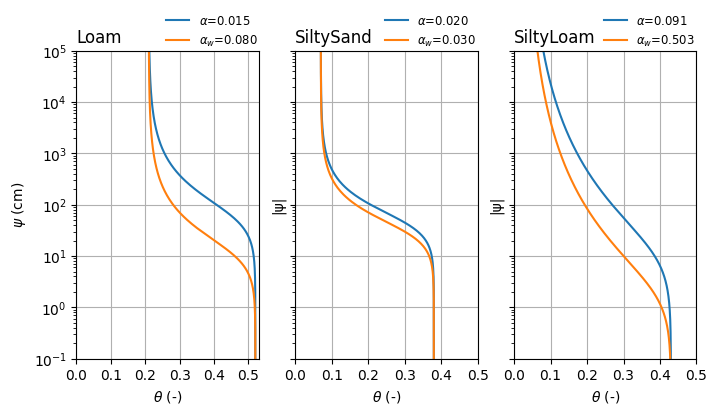

In [2]:
loam_p = {
    "k_s": 1.915,
    "theta_r": 0.21,
    "theta_s": 0.52,
    "n": 1.704,
    "alpha": 0.015,
    "xi": 5.33,
}
genk_loam = pe.Kool(xi=loam_p.pop("xi"), **loam_p)
gen_loam = pe.Genuchten(**loam_p)

siltysand = {
    "k_s": 25.92,
    "theta_r": 0.07,
    "theta_s": 0.38,
    "n": 2.02,
    "alpha": 0.02,
    "xi": 1.5,
}
genk_siltysand = pe.Kool(xi=siltysand.pop("xi"), **siltysand)
gen_siltysand = pe.Genuchten(**siltysand)

siltyloam = {
    "k_s": 137.3,
    "theta_r": 0.03,
    "theta_s": 0.43,
    "n": 1.228,
    "alpha": 0.091,
    "xi": 5.53,
}
genk_siltyloam = pe.Kool(xi=siltyloam.pop("xi"), **siltyloam)
gen_siltyloam = pe.Genuchten(**siltyloam)

f, axd = plt.subplot_mosaic(
    [["Loam", "SiltySand", "SiltyLoam"]], figsize=(8, 4), sharey=True
)
axd["Loam"].set_yscale("log")
pe.plot.swrc(gen_loam, ax=axd["Loam"], label=rf"$\alpha$={gen_loam.alpha:.3f}")
pe.plot.swrc(genk_loam, ax=axd["Loam"], label=rf"$\alpha_w$={genk_loam.alpha_w:.3f}")
pe.plot.swrc(
    gen_siltysand, ax=axd["SiltySand"], label=rf"$\alpha$={gen_siltysand.alpha:.3f}"
)
pe.plot.swrc(
    genk_siltysand,
    ax=axd["SiltySand"],
    label=rf"$\alpha_w$={genk_siltysand.alpha_w:.3f}",
)
pe.plot.swrc(
    gen_siltyloam, ax=axd["SiltyLoam"], label=rf"$\alpha$={gen_siltyloam.alpha:.3f}"
)
pe.plot.swrc(
    genk_siltyloam,
    ax=axd["SiltyLoam"],
    label=rf"$\alpha_w$={genk_siltyloam.alpha_w:.3f}",
)
for k in axd:
    axd[k].set_title(k, loc="left")
    axd[k].set_xlim(0.0)
    axd[k].set_xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5])
    axd[k].set_xlabel(r"$\theta$ (-)")
    axd[k].legend(
        bbox_to_anchor=(1.05, 0.975), loc="lower right", fontsize="small", frameon=False
    )
axd["Loam"].set_ylabel(r"$\psi$ (cm)")
_ = axd["Loam"].set_ylim(1e-1, 1e5)

## References
- Kool, J. B., and Parker, J. C. (1987). Development and evaluation of closed-form expressions for hysteretic soil hydraulic properties. Water Resources Research, 23(1), 105–114. https://doi.org/10.1029/WR023i001p00105
- Bashir, R., Sharma, J., & Stefaniak, H. (2016). Effect of hysteresis of soil-water characteristic curves on infiltration under different climatic conditions. Canadian Geotechnical Journal, 53(2), 273–284. https://doi.org/10.1139/cgj-2015-0004